# 🍔 Food Delivery Intelligence System  
## Customer Behavior, Retention Analysis, A/B Testing & Demand Forecasting

## 📌 Business Problem

A food delivery platform operating across 8 Indian cities is facing key challenges:

- High customer churn, especially after the first order  
- Inconsistent delivery performance  
- Unpredictable demand fluctuations  

This project analyzes 100,500 orders (Jan 2023 – Dec 2024) to uncover behavioral patterns, improve retention, and forecast future demand.

The goal is to enable data-driven decision-making across marketing, operations, and product teams.

## 🎯 Project Objectives

This project aims to:

- Identify high-value customers using RFM and CLTV  
- Analyze customer retention and churn behavior  
- Evaluate the effectiveness of discount strategies  
- Assess delivery performance and its impact on ratings  
- Forecast future demand across cities and cuisines  

## ❓ Key Business Questions

1. Who are the highest-value customers and what defines them?  
2. What factors contribute to customer churn after the first order?  
3. Do discounts drive repeat purchases or only one-time conversions?  
4. How does delivery delay impact customer ratings?  
5. What is the expected demand for the next 30 days by city and cuisine?  

## 👥 Stakeholders

- Marketing Team → Customer targeting and retention strategies  
- Operations Team → Delivery optimization  
- Product Team → User experience improvements  
- Finance Team → Discount and revenue optimization  

## 📊 Success Metrics

- Retention Rate  
- Churn Rate  
- Customer Lifetime Value (CLTV)  
- Average Order Value (AOV)  
- Conversion Rate (A/B Testing)  
- Average Delivery Time  
- Forecast Accuracy (MAE / RMSE)  

## 📂 Dataset Overview

The dataset contains 100,500 food delivery orders across 8 cities from Jan 2023 to Dec 2024.

Key features include:

- Order details (order_id, order_date, order_value)  
- Customer information (customer_id)  
- Delivery performance (delivery_time_mins)  
- Customer feedback (rating)  
- Discounts and payments  

##  1-LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('food_delivery_raw.csv')

In [3]:
df.head()

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,net_order_value,delivery_time_mins,prep_time_mins,order_status,payment_method,rating,is_first_order,customer_signup_date
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,12-06-2024 21:47,Bengaluru,Rolls & Wraps,127.12,5,6.36,120.76,118.0,30,Delivered,Credit Card,1.6,0,10-10-2022
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",04-11-2023 20:56,Mumbai,Rolls & Wraps,144.27,10,14.43,129.84,50.0,25,Delivered,UPI,3.9,0,25-02-2022
2,ORD0000003,CUST007327,REST0361,"Nayak, Mann and Thaker Kitchen",11-03-2024 08:29,Bengaluru,Desserts,241.70,25,60.42,181.28,46.0,15,Delivered,Cash,4.4,0,22-07-2021
3,ORD0000004,CUST011260,REST0180,Chahal Inc Kitchen,02-10-2023 16:56,Mumbai,Biryani,537.42,10,53.74,483.68,128.0,26,Delivered,UPI,2.3,0,18-02-2021
4,ORD0000005,CUST004397,REST0152,"Khatri, Bhatia and Mutti Kitchen",14-12-2023 18:02,Mumbai,Rolls & Wraps,147.87,15,22.18,125.69,48.0,25,Delivered,Wallet,NaN,0,31-07-2022


In [4]:
df.shape

(100500, 18)

In [5]:
df.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'restaurant_name',
       'order_date', 'city', 'cuisine', 'order_value', 'discount_pct',
       'discount_amount', 'net_order_value', 'delivery_time_mins',
       'prep_time_mins', 'order_status', 'payment_method', 'rating',
       'is_first_order', 'customer_signup_date'],
      dtype='object')

In [6]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100500 entries, 0 to 100499
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              100500 non-null  object 
 1   customer_id           100500 non-null  object 
 2   restaurant_id         100500 non-null  object 
 3   restaurant_name       100500 non-null  object 
 4   order_date            100500 non-null  object 
 5   city                  100500 non-null  object 
 6   cuisine               100500 non-null  object 
 7   order_value           100500 non-null  float64
 8   discount_pct          100500 non-null  int64  
 9   discount_amount       100500 non-null  float64
 10  net_order_value       100500 non-null  float64
 11  delivery_time_mins    98497 non-null   float64
 12  prep_time_mins        100500 non-null  int64  
 13  order_status          100500 non-null  object 
 14  payment_method        99493 non-null   object 
 15  

In [7]:
df.describe()

,order_value,discount_pct,discount_amount,net_order_value,delivery_time_mins,prep_time_mins,rating,is_first_order
count,100500.000000,100500.000000,100500.000000,100500.000000,98497.000000,100500.000000,70139.000000,100500.000000
mean,335.888822,9.361592,31.369345,304.967055,51.209803,21.955751,3.549416,0.081015
std,167.093674,9.162341,37.467279,155.302648,20.820605,7.306462,0.870343,0.272859
min,-99.000000,0.000000,0.000000,45.340000,15.000000,10.000000,1.500000,0.000000
25%,206.620000,0.000000,0.000000,185.040000,39.000000,15.000000,2.900000,0.000000
50%,297.725000,5.000000,19.660000,271.900000,48.000000,22.000000,3.500000,0.000000
75%,450.625000,20.000000,50.230000,404.705000,58.000000,28.000000,4.300000,0.000000
max,899.790000,25.000000,224.840000,899.490000,163.000000,34.000000,5.000000,1.000000


In [8]:
df.isnull().sum()

order_id                    0
customer_id                 0
restaurant_id               0
restaurant_name             0
order_date                  0
city                        0
cuisine                     0
order_value                 0
discount_pct                0
discount_amount             0
net_order_value             0
delivery_time_mins       2003
prep_time_mins              0
order_status                0
payment_method           1007
rating                  30361
is_first_order              0
customer_signup_date        0
dtype: int64

In [9]:
df['city'].unique()

array(['Bengaluru', 'Mumbai', 'Pune', 'Kolkata', 'Hyderabad', 'Delhi',
       'New Delhi', 'Chennai', 'Bangalore', 'MUMBAI'], dtype=object)

## ⚠️ Data Quality Observations

- City names are inconsistent (e.g., MUMBAI, Bangalore, New Delhi)  
- Negative order values exist (likely refunds)  
- Missing delivery time values (~2,000 rows)  
- Missing ratings (~30% of data)  
- Missing payment method values  

These issues will be addressed in the data cleaning phase.

## 2-🧹 Data Cleaning & Preprocessing


### 📌 Overview

The dataset contains real-world data issues such as missing values, inconsistent categorical entries, and invalid numerical values.

To ensure accurate analysis and reliable modeling, data cleaning and preprocessing steps are performed to:

- Standardize categorical variables  
- Handle missing values  
- Remove invalid records  
- Convert data types  
- Prepare data for feature engineering  

These steps improve data quality and ensure consistency across analysis.

In [10]:
df_clean = df.copy()

### 🏙️ Standardizing City Names

City names were inconsistent (e.g., "MUMBAI", "Bangalore", "New Delhi").  
These inconsistencies can lead to incorrect aggregations.

We standardize city names to ensure consistency.

In [11]:
df_clean['city'] = df_clean['city'].str.lower().str.strip()

df_clean['city'] = df_clean['city'].replace({
    'mumbai': 'Mumbai',
    'bangalore': 'Bengaluru',
    'bengaluru': 'Bengaluru',
    'new delhi': 'Delhi',
    'delhi': 'Delhi',
    'pune': 'Pune',
    'kolkata': 'Kolkata',
    'hyderabad': 'Hyderabad',
    'chennai': 'Chennai'
})

In [12]:
df_clean['city'].unique()

array(['Bengaluru', 'Mumbai', 'Pune', 'Kolkata', 'Hyderabad', 'Delhi',
       'Chennai'], dtype=object)

### 💰 Handling Negative Order Values

Negative order values were found, likely representing refunds or cancellations.

For customer behavior analysis, these records are removed to focus on valid transactions.

In [13]:
df_clean = df_clean[df_clean['order_value'] > 0]

### 📅 Converting Date Format

The order_date column is stored as a string in the format DD-MM-YYYY HH:MM.

It is converted to datetime format for time-based analysis.

In [14]:
df_clean['order_date'] = pd.to_datetime(
    df_clean['order_date'], 
    format='%d-%m-%Y %H:%M'
)

## previous

In [15]:
df['order_date'].head(1)

0    12-06-2024 21:47
Name: order_date, dtype: object

In [16]:
df_clean['order_date'].head()

0   2024-06-12 21:47:00
1   2023-11-04 20:56:00
2   2024-03-11 08:29:00
3   2023-10-02 16:56:00
4   2023-12-14 18:02:00
Name: order_date, dtype: datetime64[ns]

### 🚚 Handling Missing Delivery Time

Delivery time has missing values (~2,000 rows).

We impute missing values using the **median delivery time per city**, which preserves regional differences.

In [17]:
df_clean['delivery_time_mins'] = df_clean.groupby('city')['delivery_time_mins']\
    .transform(lambda x: x.fillna(x.median()))

### ⭐ Handling Missing Ratings

Approximately 30% of ratings are missing.

Instead of dropping these rows, missing ratings are filled with 0 to represent "no rating provided".

In [18]:
df_clean['rating'] = df_clean['rating'].fillna(0)

### 💳 Handling Missing Payment Method

Missing values in payment_method are replaced with "Unknown".

In [19]:
df_clean['payment_method'] = df_clean['payment_method'].fillna('Unknown')

### ✅ Final Data Quality Check

After cleaning, we verify:

- No missing critical values  
- Correct data types  
- Clean categorical fields  

In [20]:
df_clean.info()
df_clean.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 100400 entries, 0 to 100499
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   order_id              100400 non-null  object        
 1   customer_id           100400 non-null  object        
 2   restaurant_id         100400 non-null  object        
 3   restaurant_name       100400 non-null  object        
 4   order_date            100400 non-null  datetime64[ns]
 5   city                  100400 non-null  object        
 6   cuisine               100400 non-null  object        
 7   order_value           100400 non-null  float64       
 8   discount_pct          100400 non-null  int64         
 9   discount_amount       100400 non-null  float64       
 10  net_order_value       100400 non-null  float64       
 11  delivery_time_mins    100400 non-null  float64       
 12  prep_time_mins        100400 non-null  int64         
 13  orde

order_id                0
customer_id             0
restaurant_id           0
restaurant_name         0
order_date              0
city                    0
cuisine                 0
order_value             0
discount_pct            0
discount_amount         0
net_order_value         0
delivery_time_mins      0
prep_time_mins          0
order_status            0
payment_method          0
rating                  0
is_first_order          0
customer_signup_date    0
dtype: int64

In [21]:
df_clean.head(2)


,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,net_order_value,delivery_time_mins,prep_time_mins,order_status,payment_method,rating,is_first_order,customer_signup_date
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,2024-06-12 21:47:00,Bengaluru,Rolls & Wraps,127.12,5,6.36,120.76,118.0,30,Delivered,Credit Card,1.6,0,10-10-2022
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",2023-11-04 20:56:00,Mumbai,Rolls & Wraps,144.27,10,14.43,129.84,50.0,25,Delivered,UPI,3.9,0,25-02-2022


## 3-⚙️ Feature Engineering

### ⏱ Time-Based Features

Time-based features help analyze ordering patterns such as peak hours and weekly trends.

In [22]:
df_clean['order_hour'] = df_clean['order_date'].dt.hour
df_clean['order_day'] = df_clean['order_date'].dt.day_name()
df_clean['order_month'] = df_clean['order_date'].dt.to_period('M')
df_clean['order_weekday'] = df_clean['order_date'].dt.weekday

### 🚚 Delivery Performance Features

Delivery-related features help evaluate operational efficiency and its impact on customer satisfaction.

In [23]:
df_clean['delivery_delay'] = df_clean['delivery_time_mins']

df_clean['is_late_delivery'] = df_clean['delivery_delay'] > 30

In [24]:
df_clean[df_clean['is_late_delivery']=='False']

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,...,payment_method,rating,is_first_order,customer_signup_date,order_hour,order_day,order_month,order_weekday,delivery_delay,is_late_delivery


In [25]:
df_clean['first_order_date'] = df_clean.groupby('customer_id')['order_date'].transform('min')

df_clean['customer_lifetime_days'] = (
    df_clean['order_date'] - df_clean['first_order_date']
).dt.days

In [26]:
df_clean.head()

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,...,is_first_order,customer_signup_date,order_hour,order_day,order_month,order_weekday,delivery_delay,is_late_delivery,first_order_date,customer_lifetime_days
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,2024-06-12 21:47:00,Bengaluru,Rolls & Wraps,127.12,5,6.36,...,0,10-10-2022,21,Wednesday,2024-06,2,118.0,True,2023-01-24 16:01:00,505
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",2023-11-04 20:56:00,Mumbai,Rolls & Wraps,144.27,10,14.43,...,0,25-02-2022,20,Saturday,2023-11,5,50.0,True,2023-03-22 21:28:00,226
2,ORD0000003,CUST007327,REST0361,"Nayak, Mann and Thaker Kitchen",2024-03-11 08:29:00,Bengaluru,Desserts,241.70,25,60.42,...,0,22-07-2021,8,Monday,2024-03,0,46.0,True,2023-01-25 10:37:00,410
3,ORD0000004,CUST011260,REST0180,Chahal Inc Kitchen,2023-10-02 16:56:00,Mumbai,Biryani,537.42,10,53.74,...,0,18-02-2021,16,Monday,2023-10,0,128.0,True,2023-01-05 13:41:00,270
4,ORD0000005,CUST004397,REST0152,"Khatri, Bhatia and Mutti Kitchen",2023-12-14 18:02:00,Mumbai,Rolls & Wraps,147.87,15,22.18,...,0,31-07-2022,18,Thursday,2023-12,3,48.0,True,2023-05-14 01:40:00,214


### 💸 Discount Features

Discount-related features help analyze promotional effectiveness and A/B testing.

In [27]:
df_clean['has_discount'] = df_clean['discount_pct'] > 0

df_clean['discount_value'] = df_clean['discount_amount']

In [28]:
df_clean.head()

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,...,order_hour,order_day,order_month,order_weekday,delivery_delay,is_late_delivery,first_order_date,customer_lifetime_days,has_discount,discount_value
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,2024-06-12 21:47:00,Bengaluru,Rolls & Wraps,127.12,5,6.36,...,21,Wednesday,2024-06,2,118.0,True,2023-01-24 16:01:00,505,True,6.36
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",2023-11-04 20:56:00,Mumbai,Rolls & Wraps,144.27,10,14.43,...,20,Saturday,2023-11,5,50.0,True,2023-03-22 21:28:00,226,True,14.43
2,ORD0000003,CUST007327,REST0361,"Nayak, Mann and Thaker Kitchen",2024-03-11 08:29:00,Bengaluru,Desserts,241.70,25,60.42,...,8,Monday,2024-03,0,46.0,True,2023-01-25 10:37:00,410,True,60.42
3,ORD0000004,CUST011260,REST0180,Chahal Inc Kitchen,2023-10-02 16:56:00,Mumbai,Biryani,537.42,10,53.74,...,16,Monday,2023-10,0,128.0,True,2023-01-05 13:41:00,270,True,53.74
4,ORD0000005,CUST004397,REST0152,"Khatri, Bhatia and Mutti Kitchen",2023-12-14 18:02:00,Mumbai,Rolls & Wraps,147.87,15,22.18,...,18,Thursday,2023-12,3,48.0,True,2023-05-14 01:40:00,214,True,22.18


### 📊 RFM Preparation

Features required for customer segmentation (RFM analysis).

In [29]:
snapshot_date = df_clean['order_date'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'order_value': 'sum'
}).rename(columns={
    'order_date': 'recency',
    'order_id': 'frequency',
    'order_value': 'monetary'
})

In [30]:
rfm

,recency,frequency,monetary
customer_id,,,
CUST000001,655,5,1627.77
CUST000002,524,5,1454.37
CUST000003,560,4,1916.08
CUST000004,751,6,2321.40
CUST000005,897,8,2789.16
...,...,...,...
CUST014996,519,9,2362.07
CUST014997,565,4,1242.88
CUST014998,610,10,2569.30


In [31]:
df_clean = df_clean[df_clean['order_date'].dt.year <= 2024]

In [32]:
df_clean.head()

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,...,order_hour,order_day,order_month,order_weekday,delivery_delay,is_late_delivery,first_order_date,customer_lifetime_days,has_discount,discount_value
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,2024-06-12 21:47:00,Bengaluru,Rolls & Wraps,127.12,5,6.36,...,21,Wednesday,2024-06,2,118.0,True,2023-01-24 16:01:00,505,True,6.36
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",2023-11-04 20:56:00,Mumbai,Rolls & Wraps,144.27,10,14.43,...,20,Saturday,2023-11,5,50.0,True,2023-03-22 21:28:00,226,True,14.43
2,ORD0000003,CUST007327,REST0361,"Nayak, Mann and Thaker Kitchen",2024-03-11 08:29:00,Bengaluru,Desserts,241.70,25,60.42,...,8,Monday,2024-03,0,46.0,True,2023-01-25 10:37:00,410,True,60.42
3,ORD0000004,CUST011260,REST0180,Chahal Inc Kitchen,2023-10-02 16:56:00,Mumbai,Biryani,537.42,10,53.74,...,16,Monday,2023-10,0,128.0,True,2023-01-05 13:41:00,270,True,53.74
4,ORD0000005,CUST004397,REST0152,"Khatri, Bhatia and Mutti Kitchen",2023-12-14 18:02:00,Mumbai,Rolls & Wraps,147.87,15,22.18,...,18,Thursday,2023-12,3,48.0,True,2023-05-14 01:40:00,214,True,22.18


### ✅ Final Feature Check

Verify newly created features and dataset readiness.

In [33]:

df_clean.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'restaurant_name',
       'order_date', 'city', 'cuisine', 'order_value', 'discount_pct',
       'discount_amount', 'net_order_value', 'delivery_time_mins',
       'prep_time_mins', 'order_status', 'payment_method', 'rating',
       'is_first_order', 'customer_signup_date', 'order_hour', 'order_day',
       'order_month', 'order_weekday', 'delivery_delay', 'is_late_delivery',
       'first_order_date', 'customer_lifetime_days', 'has_discount',
       'discount_value'],
      dtype='object')

In [34]:
df_clean.head()

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,...,order_hour,order_day,order_month,order_weekday,delivery_delay,is_late_delivery,first_order_date,customer_lifetime_days,has_discount,discount_value
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,2024-06-12 21:47:00,Bengaluru,Rolls & Wraps,127.12,5,6.36,...,21,Wednesday,2024-06,2,118.0,True,2023-01-24 16:01:00,505,True,6.36
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",2023-11-04 20:56:00,Mumbai,Rolls & Wraps,144.27,10,14.43,...,20,Saturday,2023-11,5,50.0,True,2023-03-22 21:28:00,226,True,14.43
2,ORD0000003,CUST007327,REST0361,"Nayak, Mann and Thaker Kitchen",2024-03-11 08:29:00,Bengaluru,Desserts,241.70,25,60.42,...,8,Monday,2024-03,0,46.0,True,2023-01-25 10:37:00,410,True,60.42
3,ORD0000004,CUST011260,REST0180,Chahal Inc Kitchen,2023-10-02 16:56:00,Mumbai,Biryani,537.42,10,53.74,...,16,Monday,2023-10,0,128.0,True,2023-01-05 13:41:00,270,True,53.74
4,ORD0000005,CUST004397,REST0152,"Khatri, Bhatia and Mutti Kitchen",2023-12-14 18:02:00,Mumbai,Rolls & Wraps,147.87,15,22.18,...,18,Thursday,2023-12,3,48.0,True,2023-05-14 01:40:00,214,True,22.18


## 4-📊 Exploratory Data Analysis (EDA)

### 📌 Overview

Exploratory Data Analysis is performed to understand patterns in customer behavior, order trends, and operational performance.

This section focuses on identifying:

- Order trends over time  
- Customer purchasing behavior  
- Peak demand periods  
- Impact of delivery performance on ratings  

### 🔢 Univariate Analysis — Numerical Variables

This section analyzes the distribution of numerical features such as order value, delivery time, and rating.

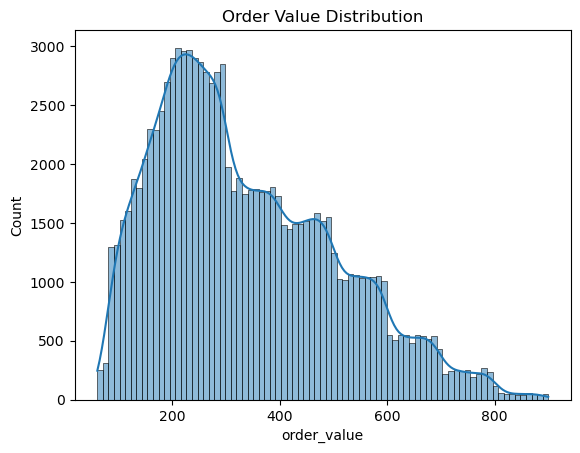

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Order Value Distribution
sns.histplot(df_clean['order_value'], kde=True)
plt.title("Order Value Distribution")
plt.show()



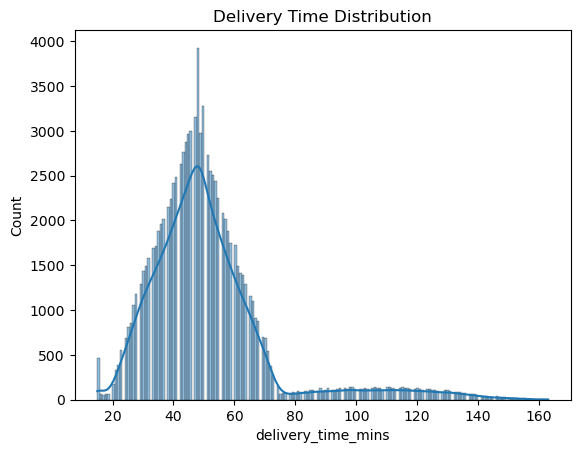

In [36]:
# Delivery Time Distribution
sns.histplot(df_clean['delivery_time_mins'], kde=True)
plt.title("Delivery Time Distribution")
plt.show()

### 🏷️ Univariate Analysis — Categorical Variables

This section examines the distribution of categorical variables such as city, cuisine, and payment method.

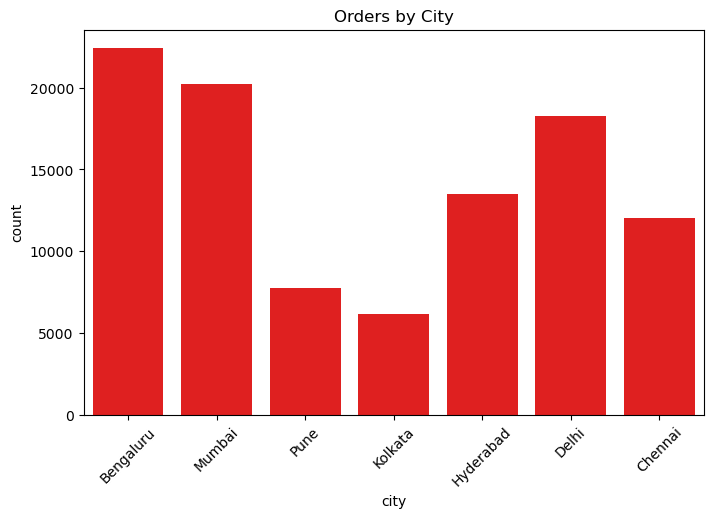

In [37]:

plt.figure(figsize=(8,5))
sns.countplot(x='city', data=df_clean,color='red')
plt.title("Orders by City")
plt.xticks(rotation=45)
plt.show()

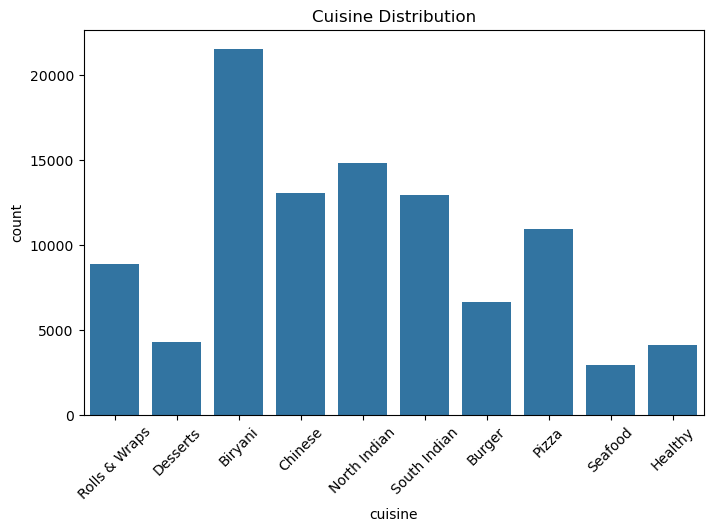

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x='cuisine',data=df_clean)
plt.title("Cuisine Distribution")
plt.xticks(rotation=45)
plt.show()

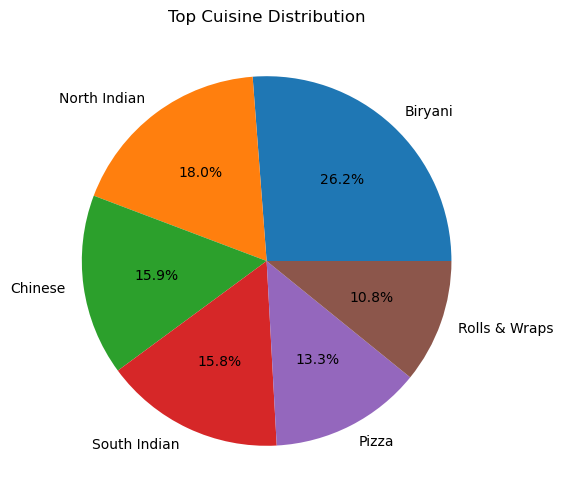

In [39]:
cuisine_counts = df_clean['cuisine'].value_counts().head(6)

plt.figure(figsize=(6,6))
plt.pie(cuisine_counts, labels=cuisine_counts.index, autopct='%1.1f%%')
plt.title("Top Cuisine Distribution")
plt.show()

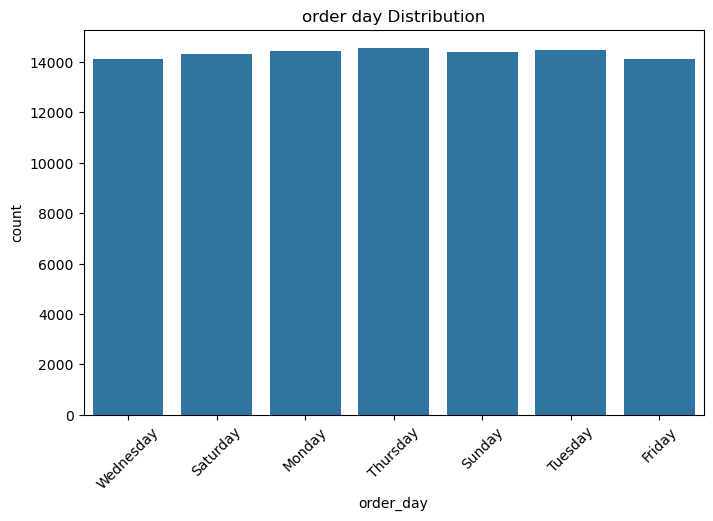

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x='order_day',data=df_clean)
plt.title("order day Distribution")
plt.xticks(rotation=45)
plt.show()



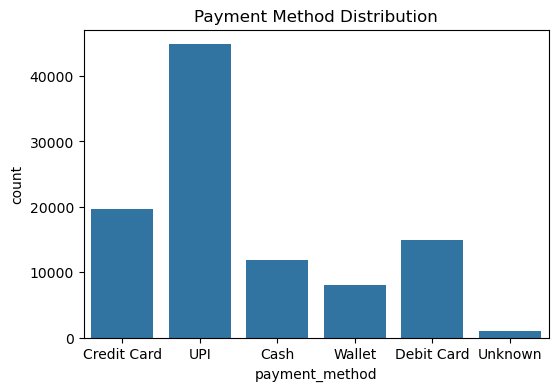

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='payment_method', data=df_clean)
plt.title("Payment Method Distribution")
plt.show()

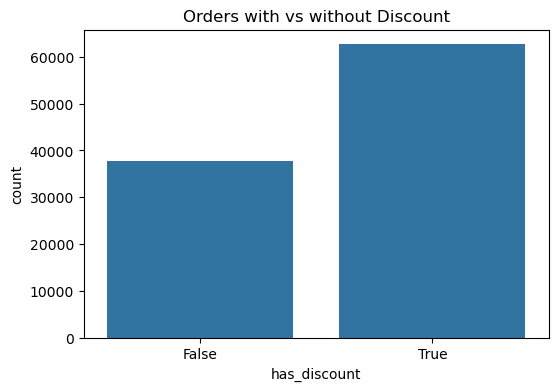

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='has_discount', data=df_clean)
plt.title("Orders with vs without Discount")
plt.show()

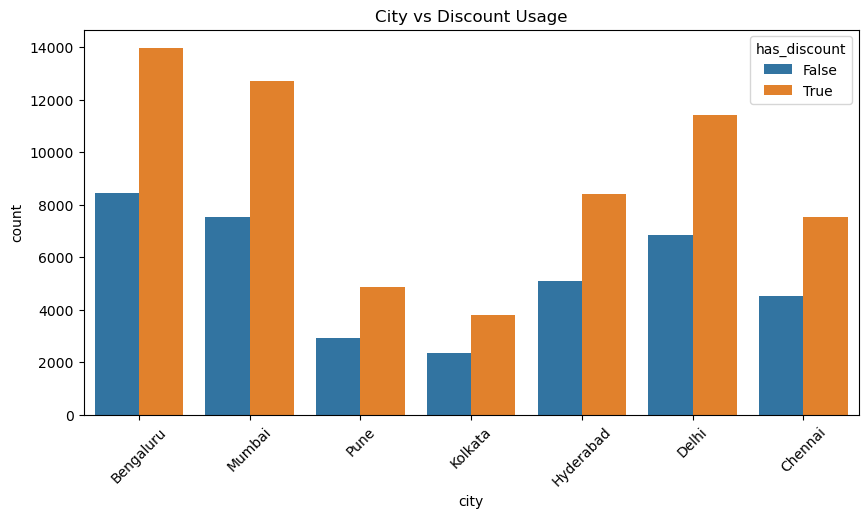

In [43]:
plt.figure(figsize=(10,5))
sns.countplot(x='city', hue='has_discount', data=df_clean)
plt.title("City vs Discount Usage")
plt.xticks(rotation=45)
plt.show()

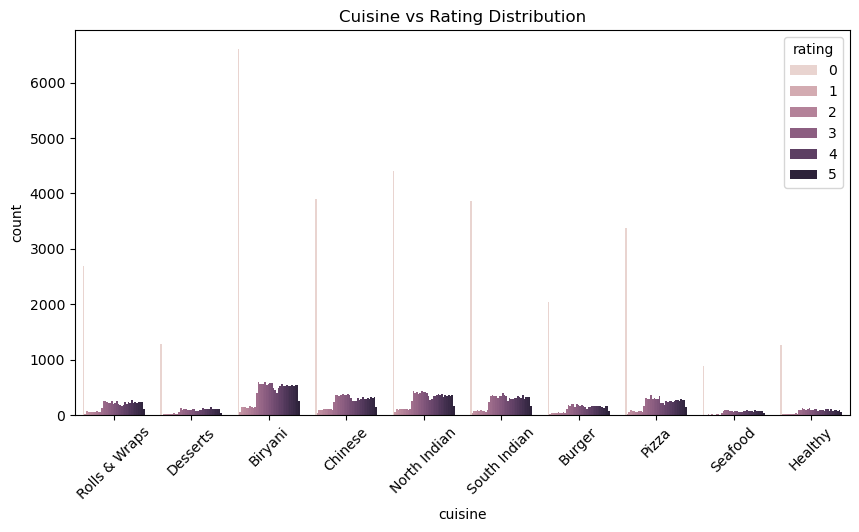

In [44]:
plt.figure(figsize=(10,5))
sns.countplot(x='cuisine', hue='rating', data=df_clean)
plt.title("Cuisine vs Rating Distribution")
plt.xticks(rotation=45)
plt.show()

In [45]:
df_clean['discount_category'] = pd.cut(
    df_clean['discount_pct'],
    bins=[-1, 0, 10, 20, 50, 100],
    labels=['No Discount', '0-10%', '10-20%', '20-50%', '50%+']
)

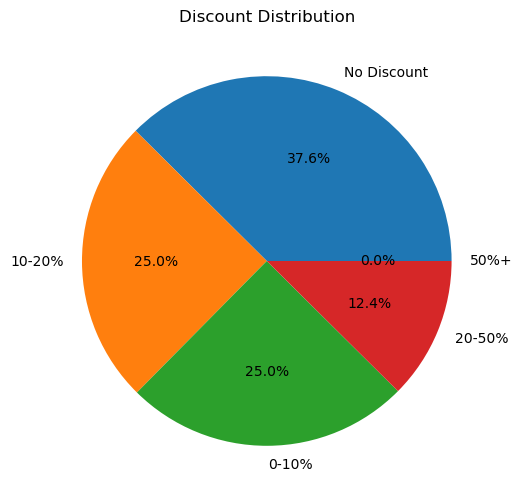

In [46]:
discount_counts = df_clean['discount_category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(discount_counts, labels=discount_counts.index, autopct='%1.1f%%')
plt.title("Discount Distribution")
plt.show()

<Axes: xlabel='city'>

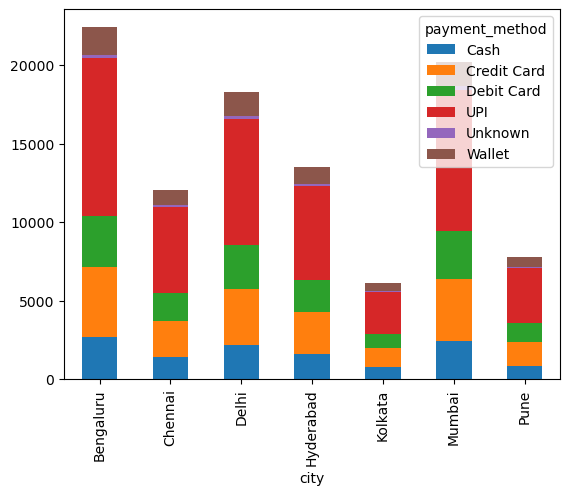

In [47]:
pd.crosstab(df_clean['city'], df_clean['payment_method']).plot(kind='bar', stacked=True)

<Axes: xlabel='cuisine'>

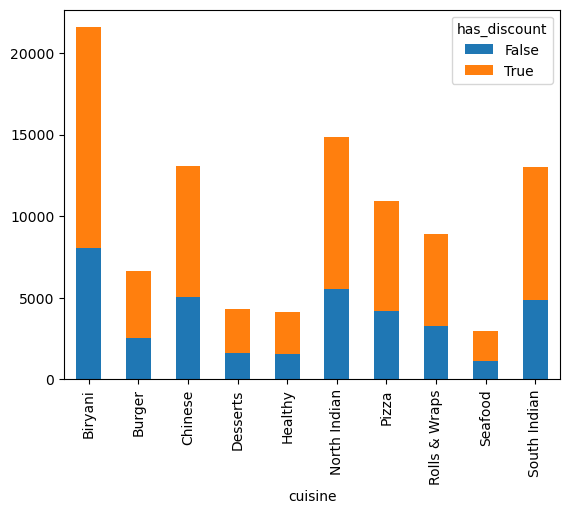

In [48]:
pd.crosstab(df_clean['cuisine'], df_clean['has_discount']).plot(kind='bar', stacked=True)

In [49]:
monthly_revenue = df_clean.groupby('order_month')['order_value'].sum()

monthly_revenue

order_month
2023-01    1452633.66
2023-02    1307930.13
2023-03    1405269.86
2023-04    1389224.28
2023-05    1457434.97
2023-06    1356508.23
2023-07    1413077.45
2023-08    1414126.74
2023-09    1411918.30
2023-10    1412484.16
2023-11    1397117.53
2023-12    1428924.04
2024-01    1456061.24
2024-02    1358990.62
2024-03    1445274.95
2024-04    1363503.90
2024-05    1458031.32
2024-06    1388546.02
2024-07    1451036.30
2024-08    1371422.28
2024-09    1360418.12
2024-10    1409762.39
2024-11    1375627.14
2024-12    1463789.42
Freq: M, Name: order_value, dtype: float64

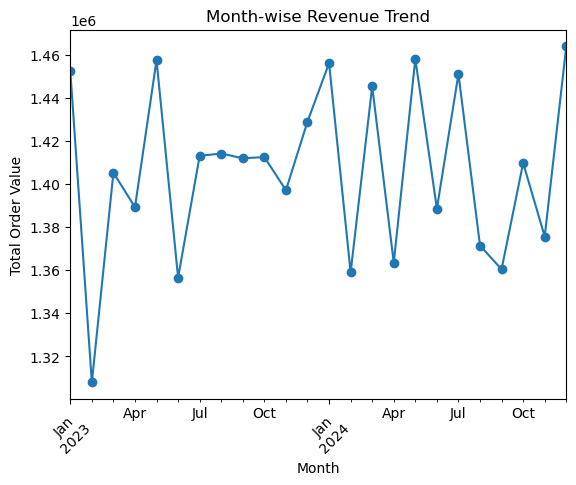

In [50]:


monthly_revenue.plot(marker='o')
plt.title("Month-wise Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Order Value")
plt.xticks(rotation=45)
plt.show()

In [51]:
monthly_orders = df_clean.groupby('order_month').size()

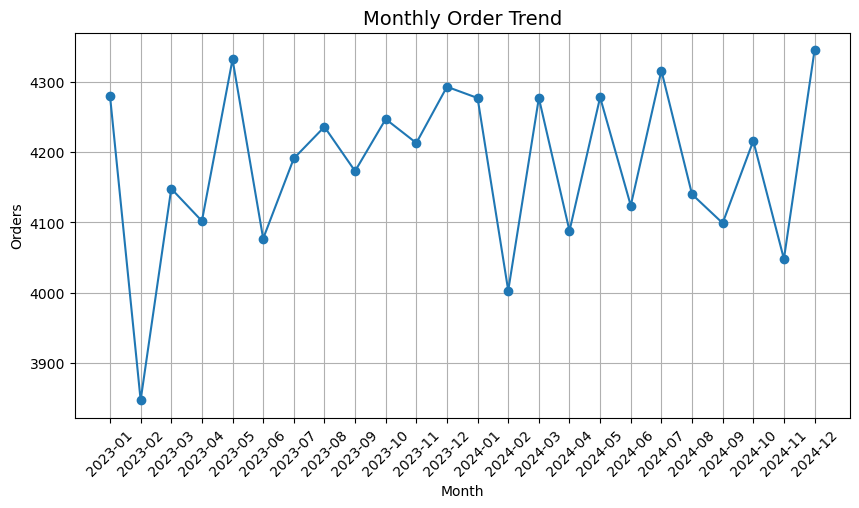

In [52]:
import matplotlib.pyplot as plt

monthly_orders = df_clean.groupby('order_month').size()
monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_orders.index, monthly_orders.values, marker='o')
plt.title("Monthly Order Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

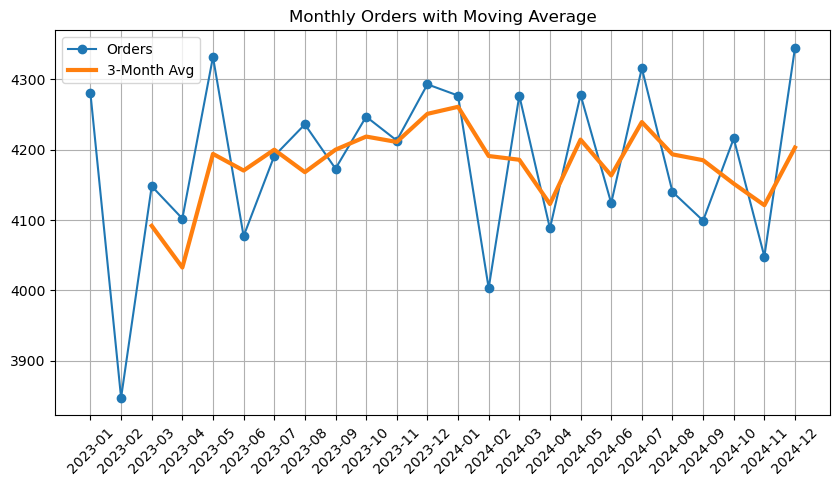

In [53]:
monthly_orders_ma = monthly_orders.rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_orders.index, monthly_orders.values, label='Orders', marker='o')
plt.plot(monthly_orders.index, monthly_orders_ma.values, label='3-Month Avg', linewidth=3)

plt.title("Monthly Orders with Moving Average")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

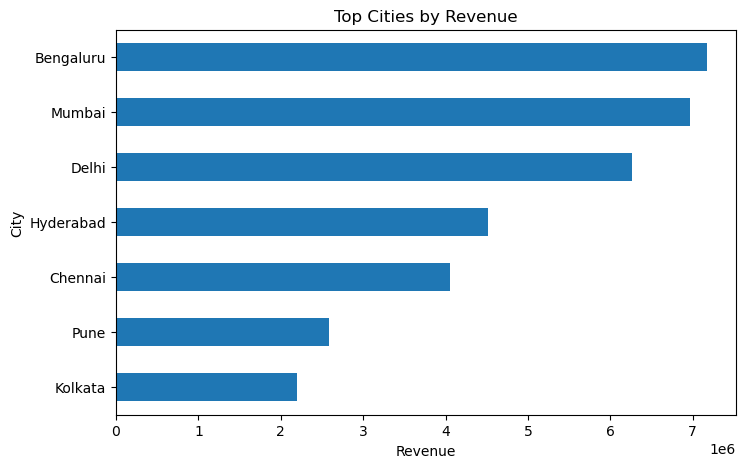

In [54]:
city_revenue = df_clean.groupby('city')['order_value'].sum().sort_values()

plt.figure(figsize=(8,5))
city_revenue.plot(kind='barh')
plt.title("Top Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")
plt.show()

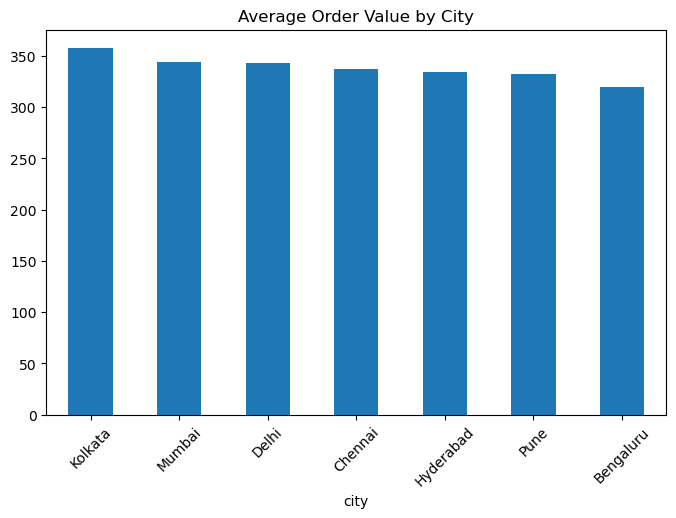

In [55]:
aov_city = df_clean.groupby('city')['order_value'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
aov_city.plot(kind='bar')
plt.title("Average Order Value by City")
plt.xticks(rotation=45)
plt.show()

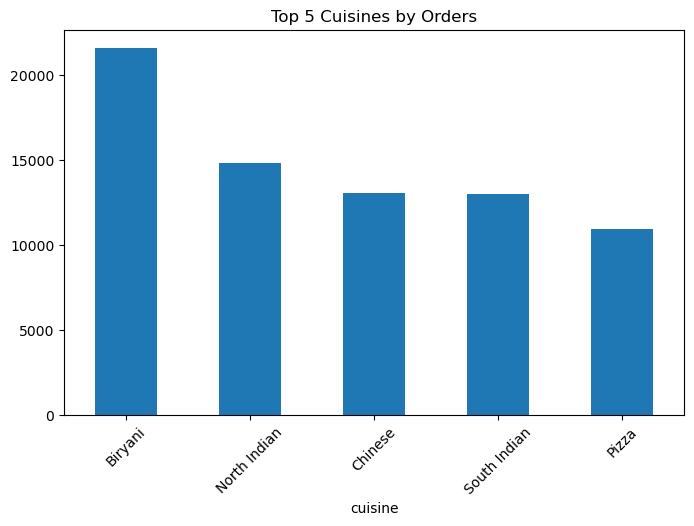

In [56]:
top_cuisine = df_clean['cuisine'].value_counts().head(5)

plt.figure(figsize=(8,5))
top_cuisine.plot(kind='bar')
plt.title("Top 5 Cuisines by Orders")
plt.xticks(rotation=45)
plt.show()

In [57]:
df_clean['delay_category'] = pd.cut(
    df_clean['delivery_time_mins'],
    bins=[0,20,40,60,100],
    labels=['Fast','Moderate','Slow','Very Slow']
)

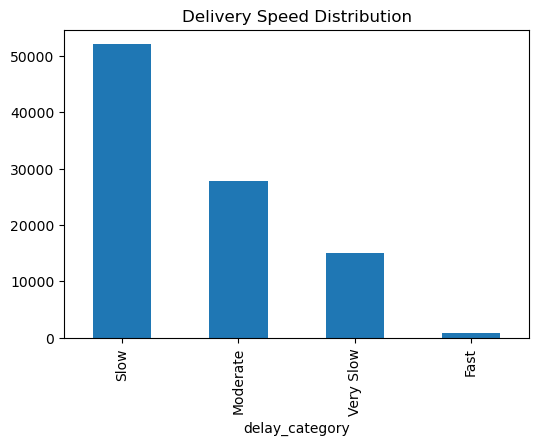

In [58]:
delay_dist = df_clean['delay_category'].value_counts()

plt.figure(figsize=(6,4))
delay_dist.plot(kind='bar')
plt.title("Delivery Speed Distribution")
plt.show()

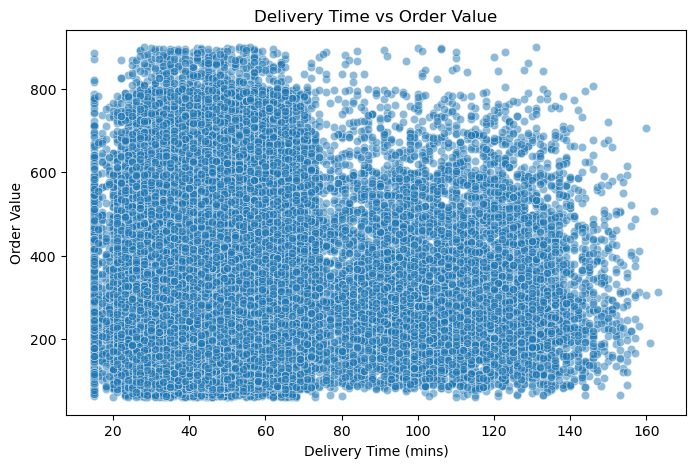

In [59]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='delivery_time_mins', y='order_value', data=df_clean, alpha=0.5)

plt.title("Delivery Time vs Order Value")
plt.xlabel("Delivery Time (mins)")
plt.ylabel("Order Value")
plt.show()

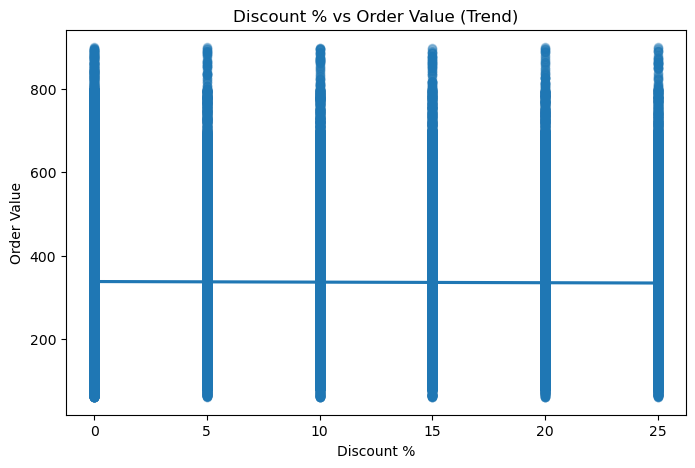

In [60]:
plt.figure(figsize=(8,5))
sns.regplot(x='discount_pct', y='order_value', data=df_clean, scatter_kws={'alpha':0.3})

plt.title("Discount % vs Order Value (Trend)")
plt.xlabel("Discount %")
plt.ylabel("Order Value")
plt.show()

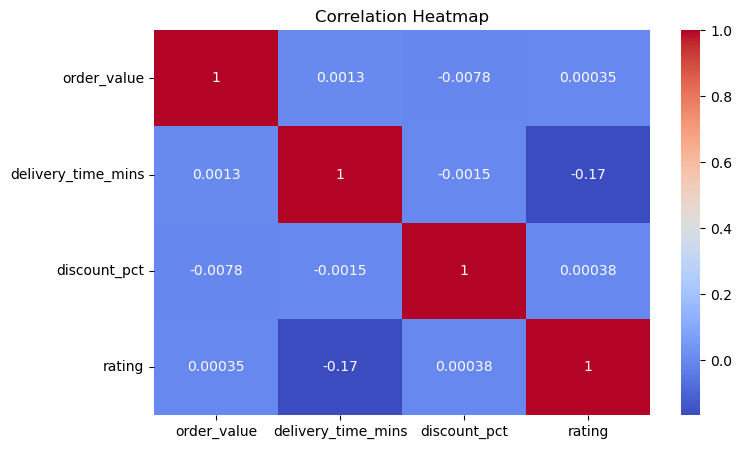

In [61]:
plt.figure(figsize=(8,5))

corr = df_clean[['order_value','delivery_time_mins','discount_pct','rating']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

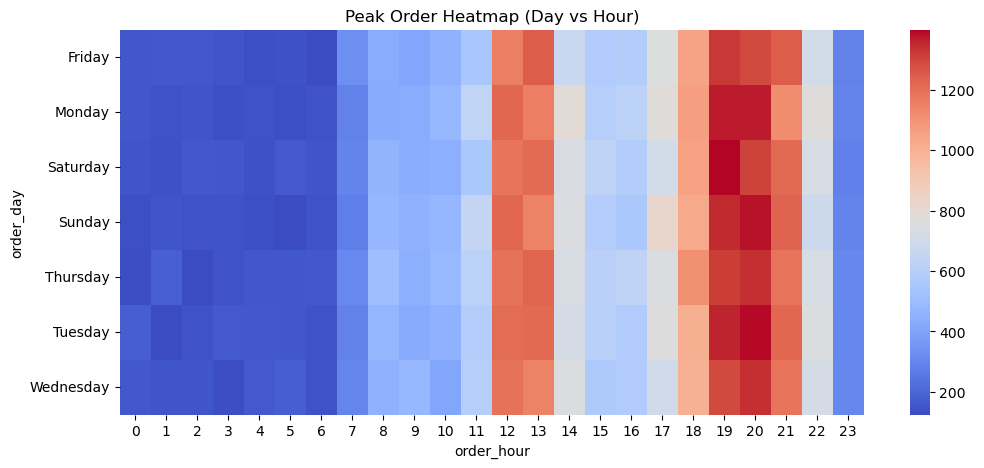

In [62]:
heat = df_clean.groupby(['order_day','order_hour']).size().unstack()

import seaborn as sns
plt.figure(figsize=(12,5))
sns.heatmap(heat, cmap='coolwarm')
plt.title("Peak Order Heatmap (Day vs Hour)")
plt.show()

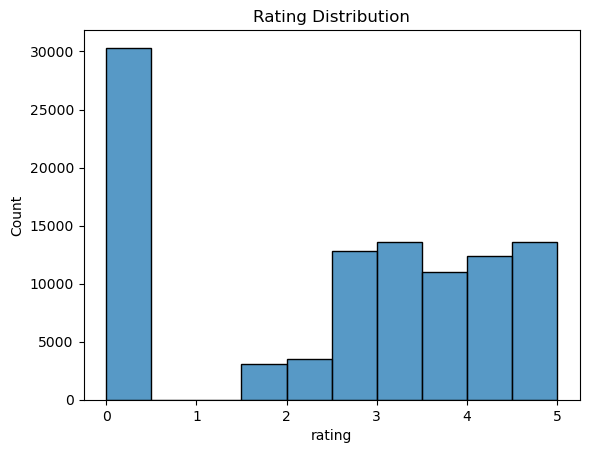

In [63]:
sns.histplot(df_clean['rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

### 🔍 Key Insights

- Orders show strong seasonal and time-based trends  
- Certain cities and cuisines dominate revenue  
- Delivery performance impacts ratings significantly  
- Discounts influence purchasing behavior  
- Customer satisfaction varies across segments  

In [64]:
df_clean.head()

,order_id,customer_id,restaurant_id,restaurant_name,order_date,city,cuisine,order_value,discount_pct,discount_amount,...,order_month,order_weekday,delivery_delay,is_late_delivery,first_order_date,customer_lifetime_days,has_discount,discount_value,discount_category,delay_category
0,ORD0000001,CUST010401,REST0487,Radhakrishnan Ltd Kitchen,2024-06-12 21:47:00,Bengaluru,Rolls & Wraps,127.12,5,6.36,...,2024-06,2,118.0,True,2023-01-24 16:01:00,505,True,6.36,0-10%,NaN
1,ORD0000002,CUST007934,REST0116,"Bera, Narula and Sridhar Kitchen",2023-11-04 20:56:00,Mumbai,Rolls & Wraps,144.27,10,14.43,...,2023-11,5,50.0,True,2023-03-22 21:28:00,226,True,14.43,0-10%,Slow
2,ORD0000003,CUST007327,REST0361,"Nayak, Mann and Thaker Kitchen",2024-03-11 08:29:00,Bengaluru,Desserts,241.70,25,60.42,...,2024-03,0,46.0,True,2023-01-25 10:37:00,410,True,60.42,20-50%,Slow
3,ORD0000004,CUST011260,REST0180,Chahal Inc Kitchen,2023-10-02 16:56:00,Mumbai,Biryani,537.42,10,53.74,...,2023-10,0,128.0,True,2023-01-05 13:41:00,270,True,53.74,0-10%,NaN
4,ORD0000005,CUST004397,REST0152,"Khatri, Bhatia and Mutti Kitchen",2023-12-14 18:02:00,Mumbai,Rolls & Wraps,147.87,15,22.18,...,2023-12,3,48.0,True,2023-05-14 01:40:00,214,True,22.18,10-20%,Slow


In [65]:
df_clean.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'restaurant_name',
       'order_date', 'city', 'cuisine', 'order_value', 'discount_pct',
       'discount_amount', 'net_order_value', 'delivery_time_mins',
       'prep_time_mins', 'order_status', 'payment_method', 'rating',
       'is_first_order', 'customer_signup_date', 'order_hour', 'order_day',
       'order_month', 'order_weekday', 'delivery_delay', 'is_late_delivery',
       'first_order_date', 'customer_lifetime_days', 'has_discount',
       'discount_value', 'discount_category', 'delay_category'],
      dtype='object')

In [67]:
df_clean.to_csv("clean_data_full.csv", index=False)